In [42]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten,Dense,Input
from tensorflow.keras.utils import to_categorical

In [3]:
(train_images,train_labels),(test_images,test_labels) = fashion_mnist.load_data()

In [ ]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 28, 28)


9
0
0
3
0
2


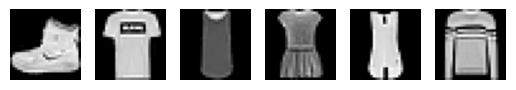

In [41]:
plt.figure()
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(train_images[i],cmap='gray')
    print(train_labels[i])
    plt.axis("off")
plt.show()

In [24]:
img_test = test_images/255
img_train = train_images/255
print(img_test[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [45]:
img_train = img_train.reshape(-1,28*28)
img_test = img_test.reshape(-1,28*28)

In [46]:
lbl_train = to_categorical(train_labels,10)
lbl_test = to_categorical(test_labels,10)
print(lbl_test[0],test_labels[0])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.] 9


In [49]:
model = Sequential([
    Input(shape=(784,)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
]
)
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [54]:
his = model.fit(img_train,lbl_train,epochs=8,batch_size=32)

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8210 - loss: 0.5011
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8639 - loss: 0.3731
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8757 - loss: 0.3358
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8856 - loss: 0.3109
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8916 - loss: 0.2927
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8946 - loss: 0.2805
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9014 - loss: 0.2657
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9046 - loss: 0.2552


In [ ]:
evaluation = model.evaluate(img_test,lbl_test)
print(evaluation) 
# we got higher loss and lower acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8801 - loss: 0.3496
[0.34955310821533203, 0.8801000118255615]


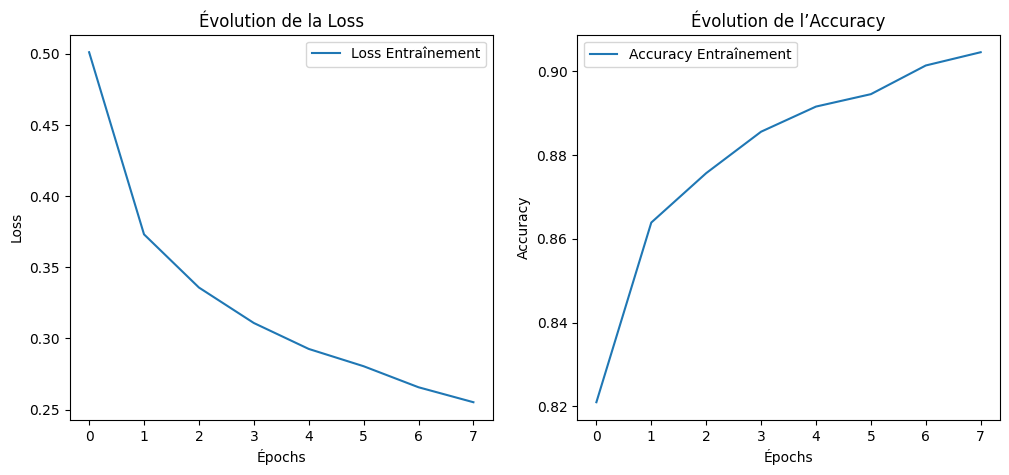

In [56]:
train_loss = his.history['loss']
train_acc = his.history['accuracy']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Loss Entraînement')
plt.xlabel('Épochs')
plt.ylabel('Loss')
plt.title('Évolution de la Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Accuracy Entraînement')
plt.xlabel('Épochs')
plt.ylabel('Accuracy')
plt.title('Évolution de l’Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


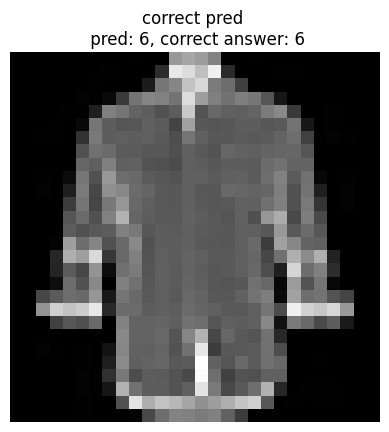

In [95]:
from operator import indexOf
import random
random_number = random.randint(1, 10000)
prediction = model.predict(img_test)
pred_label = np.argmax(prediction, axis=1)
plt.figure()
plt.imshow(img_test[random_number].reshape(28,28),cmap='gray')
if pred_label[random_number] == indexOf(lbl_test[random_number],1):
    plt.title(f"correct pred \n pred: {pred_label[random_number]}, correct answer: {indexOf(lbl_test[random_number],1)}")
else:
    plt.title(f"wrong pred \n pred: {pred_label[random_number]}, correct answer: {indexOf(lbl_test[random_number],1)}")
plt.axis("off")
plt.show()